


# Energy Efficiency Prediction Model

## Introduction

**What is the goal of this lab?**

This lab goes over the steps to build a linear regression model with both categorical and numerical features, along with the statistical tests that should be run to help better understand the data for the model.

**Context**

Linear regression is one of the most fundamental and widely used tools in data analysis. Its simplicity makes it an ideal starting point for understanding the basics of predictive modeling. By establishing a relationship between variables, linear regression allows us to make informed predictions and gain insights into data trends. Mastering linear regression is essential for developing the skills needed to analyze and interpret data effectively, laying the groundwork for more advanced analytical techniques.


### Data

This lab uses the energy efficieny data set 💡. It contains data about the energy efficiency of shapes and specifications of buildings.

For more information you can check out the original research paper that introduced this data set [Accurate quantitative estimation of energy performance of residential buildings using statistical machine learning tools](https://www.sciencedirect.com/science/article/pii/S037877881200151X).

In [ ]:
# Install package to download data sets from UCI ML Repo
!pip3 install -U ucimlrepo --quiet
from ucimlrepo import fetch_ucirepo

In [ ]:
# Get the data set
energy = fetch_ucirepo(name="Energy Efficiency")

In [ ]:
# Get raw data in a pandas.DataFrame format
energy_df = energy.data.original

In [ ]:
# Citation
print("Citation:\n", energy.metadata.additional_info.citation)

Citation:
 None


> _Tsanas, Athanasios and Xifara, Angeliki. (2012). Energy Efficiency.     
UCI Machine Learning Repository. https://doi.org/10.24432/C51307._

In [ ]:
# More information
print("Check out this data set on the UCI ML Repository for more information:")
print(energy.metadata.repository_url)

Check out this data set on the UCI ML Repository for more information:
https://archive.ics.uci.edu/dataset/242/energy+efficiency


## Problem Statement

**Why could it be beneficial to predict the heating or cooling amount of energy for a building? Explain 2 possible reasons or use cases.**

*One reason I could think of is saving the electricity cost, if people know if the temperature has reached the desirable leve, they can turn off/on the heater or cooler hence saving cost effectively.
Another reason why it is beneficial to predict energy amount is to prevent any energy loss and make people uncomfortable.*




**List all the key assumptions of linear regression, including linearity, independence of errors, homoscedasticity, normality of errors, and absence of multicollinearity. For each assumption:**

- **Provide a brief explanation of its significance in the context of the model.**
- **Specify at least one statistical test or diagnostic plot you would use to validate it.**
- **Include an example scenario where a violation of the assumption might occur and its potential impact on the model.**

*1) Linearity: I think it is significant because we initially assume the data has a linear relationship between the independent and dependant variable. we can check this by comparing the our predictions with actual data values and ideally it should look random scatter, and not a curve. If our tests are show a curve pattern then our this straight line model won't fit well and predicting values will be off.*


*2) Independence of Errors:the Errors are believed to be independent of each other, else the model won't be able to differentiate about which matters. One way we can check is by checking how much features are correlated. One scenario could if what if the feature have same values but with a different SI unit C(Celsius) or F(Fahrenheit), the model does not know that and so can cause errors in predicting.*


*3) Homoscedasticity: It just mean the variance of error is assummed to be fixed.One way we can check is by ploting the errors against our predicted values, result should be evenly spread out. If not constant, the significance test will be wrong and unreliable.*

*4) Normality of Errors:The errors are assumed to have a normally distributed graph. we can use a Q-Q graph to see if error look like a normal distribution. If errors get bigger or smaller for some value then we can say the model's predictions are not accurate*


## Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Inspection

Print out the following details about the data:
- The first 5 rows of the data set
- Number of rows and columns
- Data type of each column
- Number of null values (or not-null values) in each column
- General statistics of each numeric column (min, max, mean, standard deviation)

---

**Hints**

- [`pandas.DataFrame.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
- [`pandas.DataFrame.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)
- [`pandas.DataFrame.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

In [ ]:
!pip3 install -U ucimlrepo --quiet
from ucimlrepo import fetch_ucirepo
energy = fetch_ucirepo(name="Energy Efficiency")
energy_df = energy.data.original

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(energy_df.head(5))
print(energy_df.shape)
print(energy_df.dtypes)
print(energy_df.isnull().sum())
print(energy_df.describe())




     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28
(768, 10)
X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
X6      int64
X7    float64
X8      int64
Y1    float64
Y2    float64
dtype: object
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64
               X1          X2          X3          X4         X5          X6  \
count  768.000000  768.000000  768.000000  768.000000  768.00000  768.000000   
mean     0.764167  671.708333  318.500000  176.604167    5.25000    3.500000   
std      0.105777   88.086116   43.626481   45.165950    1.75114    1.118763   
min      0.620000  514.500000  245.000000  110.2500

### Data cleaning

The default column names are not very descriptive. Rename the columns according to this mapping of names adapted from the data set description.

```python
{
    'X1': 'relative_compactness',
    'X2': 'surface_area',
    'X3': 'wall_area',
    'X4': 'roof_area',
    'X5': 'overall_height',
    'X6': 'orientation',
    'X7': 'glazing_area',
    'X8': 'glazing_area_distribution',
    'Y1': 'heating_load',
    'Y2': 'cooling_load',
}
```

---
**Hints**
- [`pandas.DataFrame.rename()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html)

In [ ]:
energy_df = energy_df.rename(columns={
    'X1': 'relative_compactness',
    'X2': 'surface_area',
    'X3': 'wall_area',
    'X4': 'roof_area',
    'X5': 'overall_height',
    'X6': 'orientation',
    'X7': 'glazing_area',
    'X8': 'glazing_area_distribution',
    'Y1': 'heating_load',
    'Y2': 'cooling_load',
})

The variables `"orientation"` and `"glazing_area_distribution"` are categorical variables which currently have numeric indicies. Convert this index values into more descriptive names using this mapping.


```python
{
    0: 'No glazing',
    1: 'Uniformly distributed',
    2: 'North',
    3: 'East',
    4: 'South',
    5: 'West'
}
```

---
**Hints**

- [`pandas.Series.replace()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.replace.html)

In [ ]:
energy_df['orientation'] = energy_df['orientation'].replace({
    0: 'No glazing',
    1: 'Uniformly distributed',
    2: 'North',
    3: 'East',
    4: 'South',
    5: 'West'
})
energy_df['glazing_area_distribution'] = energy_df['glazing_area_distribution'].replace({

    0: 'No glazing',
    1: 'Uniformly distributed',
    2: 'North',
    3: 'East',
    4: 'South',
    5: 'West'

})



### Data Visualization and Statistics

Our model will attempt to predict `"heating_load"` with 2 categorical variables `"orientation"` & `"glazing_area_distribution"`, and 2 numeric variables `"surface_area"` & `"wall_area"`.

1. First, we will create graphs to **visualize** the relationship between each of these variables and the heating load.

2. Second, we will do some **statistical tests** to determine if each individual variable has a statistically significant relationship with heating load.

These steps will help us determine which features to use in the model.


#### Visualizations

Create plots to visualize the relationship of each of the four variables with heating load. For each graph the Y-axis should be heating load `y="heating_load"`, and the X-axis should be the other variable. Create box plots for the categorical variables and scatter plots for the numeric variables.


---
**Hints**
- [`seaborn.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html)
- [`seaborn.scatterplot()`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)



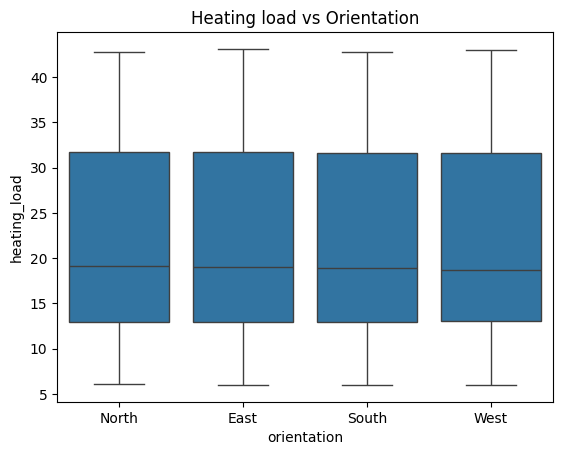

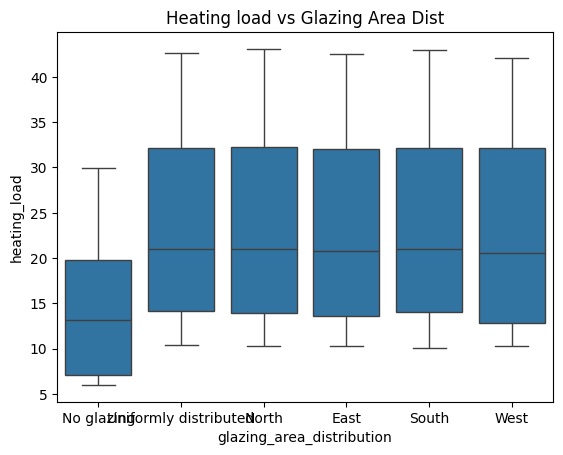

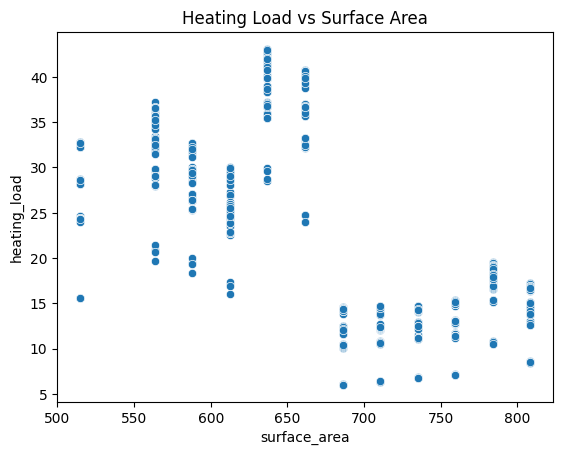

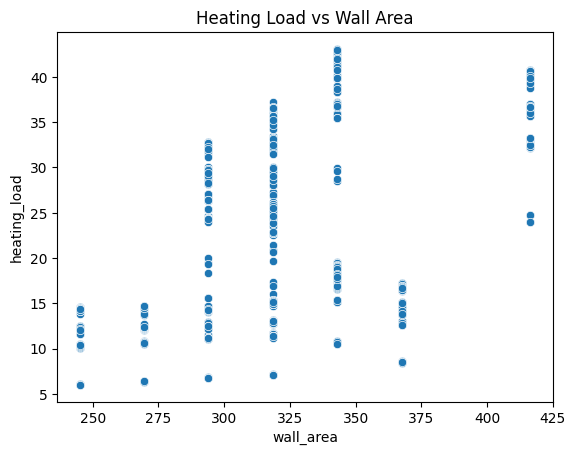

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.boxplot(x="orientation", y="heating_load", data=energy_df)
plt.title("Heating load vs Orientation")
plt.show()

sns.boxplot(x="glazing_area_distribution", y="heating_load", data=energy_df)
plt.title("Heating load vs Glazing Area Dist")
plt.show()

sns.scatterplot(x="surface_area", y="heating_load",data=energy_df)
plt.title('Heating Load vs Surface Area')
plt.show()

sns.scatterplot(x="wall_area", y="heating_load",data=energy_df)
plt.title('Heating Load vs Wall Area')
plt.show()

#### Statistics

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

Run statistical tests to analyze the relationship of each of the four variables with heating load. Each test will result in a p-value to determine if the relationship is statistically significant, which is an indiciation that would be a useful feature for the model. Run *ANOVA for the categorical* variables and *OLS for the numeric variables*. Print out F-statistic and p-value of each test.

---
**Hints**
- [`statsmodels.formula.api.ols()`](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html)
- [`statsmodels.stats.anova.anova_lm()`](https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html)


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

categorial_vars = ['orientation','glazing_area_distribution']
numeric_vars = ['surface_area','wall_area']

#ANOVA for the categorical variables for (orientation, glazing_area_distribution)
for cat_variable in categorial_vars:
    c_model = ols(f'heating_load ~C({cat_variable})',data=energy_df).fit()
    anova_results = anova_lm(c_model)
    print(anova_results[['F','PR(>F)']],"\n")


#OLS for the numeric variables "surface_area" & "wall_area"
for num_variable in numeric_vars:
    n_model = ols(f'heating_load ~({num_variable})',data =energy_df).fit()
    print(f"F value for {num_variable}: {n_model.fvalue}")
    print(f"P value for {num_variable}: {n_model.f_pvalue}")
    print("\n")


                       F    PR(>F)
C(orientation)  0.005436  0.999448
Residual             NaN       NaN 

                                     F    PR(>F)
C(glazing_area_distribution)  6.740745  0.000004
Residual                           NaN       NaN 

F value for surface_area: 585.261320249545
P value for surface_area: 1.686907290214673e-96


F value for wall_area: 200.72766110921035
P value for wall_area: 1.2218886883323984e-40




## Models

Create a linear regression model using only the variables that showed a significant effect on heating load based on the p-values calculated above. Compare the results of doing this with the Statsmodels vs. Scikit-Learn.

#### Statsmodels

Create an [OLS](https://en.wikipedia.org/wiki/Ordinary_least_squares) linear regression model using the Statsmodels package to predict heating load using only the signifant variables from the EDA analysis. Then print out the model summary.

---
**Hints**

- [`statsmodels.formula.api.ols()`]()
    - Use this to run the linear regression
- [`statsmodels.regression.linear_model.RegressionResults.summary()`](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html#statsmodels.regression.linear_model.RegressionResults)
    - This is the type of object it returns. Run the `.summary()` method to print out the model summary.

In [ ]:
import statsmodels.formula.api as smf

formula = 'heating_load ~ surface_area + wall_area +C(glazing_area_distribution)'

model = smf.ols(formula=formula, data=energy_df).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           heating_load   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     532.0
Date:                Wed, 08 Oct 2025   Prob (F-statistic):          6.62e-288
Time:                        01:08:59   Log-Likelihood:                -2183.0
No. Observations:                 768   AIC:                             4382.
Df Residuals:                     760   BIC:                             4419.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

#### Scikit-Learn

Create a linear regression model using Scikit Learn to predict heating load using only the signifant variables from the EDA analysis. Then print out the coefficients and intercept of the model.

---
**Hints**
- [`sklearn.preprocessing.OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
- [`sklearn.linear_model.LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

#features
df = energy_df[['surface_area', 'wall_area', 'heating_load','glazing_area_distribution']]
x = df[['surface_area', 'wall_area']]
y = df['heating_load']

encoder = OneHotEncoder(sparse_output=False,drop='first')
glazing_encoded = encoder.fit_transform(df[['glazing_area_distribution']])

glazing_encoded_df = pd.DataFrame(glazing_encoded, columns=encoder.get_feature_names_out(['glazing_area_distribution']))
X_result = pd.concat([x, glazing_encoded_df], axis=1)

#model
model = LinearRegression()
model.fit(X_result, y)

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)




Coefficient: [-8.89931078e-02  1.40519232e-01 -8.39500000e+00  2.52986111e-01
  2.05208333e-01  3.44652778e-01 -5.55555556e-04]
Intercept: 37.70349520431943


Calculate the predictions of both models on the training data set. Then calculate the mean absolute error (MAE) and root mean squared error (RMSE) of those predictions.

---
**Hints**

- [`statsmodels.base.model.Model.predict()`](https://www.statsmodels.org/stable/dev/generated/statsmodels.base.model.Model.html#statsmodels.base.model.Model)
- [`sklearn.linear_model.LinearRegression.predict()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [`sklearn.metrics.mean_absolute_error()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)
- [`sklearn.metrics.mean_squared_error()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error

x = energy_df[['surface_area', 'wall_area']]
y = energy_df['heating_load']

model = LinearRegression()
model.fit(x, y)

scikit_model = LinearRegression()
scikit_model.fit(x, y)
scikit_predict = scikit_model.predict(x)

X_statmodel = sm.add_constant(x)
s_model = sm.OLS(y, X_statmodel).fit()
stats_predict = s_model.predict(X_statmodel)

#scikit
mae_scikit = mean_absolute_error(y, scikit_predict)
rmse_scikit = np.sqrt(mean_squared_error(y, scikit_predict))

#stat model
mae_stats = mean_absolute_error(y, stats_predict)
rmse_stats = np.sqrt(mean_squared_error(y, stats_predict))

#prints
print("Scikit MAE:", mae_scikit)
print("Scikit RMSE:", rmse_scikit)

print("Stats MAE:", mae_stats)
print("Stats RMSE:", rmse_stats)





Scikit MAE: 3.273585291983737
Scikit RMSE: 4.641334193225396
Stats MAE: 3.273585291983737
Stats RMSE: 4.641334193225396


## Conclusion

**Which variables should a statistically significant relationship with heating load in the statistical tests? Does that match what is visualized in the graphs?**

*Surface_area, wall_area and glazing_area_distribution were found to be significant because there p value was calculated to be less than < 0.05 Yes, we can see this in the boxplot plot and scatter plot graphs and stats test also verifies this.*

**Evaluate the $R^2$, $p-value$, and $F-statistic$ from the multivariable OLS linear regression model. Do these value indicate that the model is a good fit to the data? Why or why not?**

*R2 = 0.83 means it is 83% of the variation a very good fit to the data.
F-statistic = 532 which mean the model is very significant.
p value is close to almost 0 and so high significant as anything p value < 0.05 is considered significant*


**Evaluate the coefficients from both the Statsmodels OLS and Scikit Learn Linear Regression model. How similar are they? What are any differences?**

*The coefficients from both statsmodel and scikit learn are similar. only minor or differnce at all below I pasted some for comparison.*

*Variable->Statsmodels Coef->Scikit-Learn Coef*

*Intercept:    37.7035:  37.7035*

*surface_area:	-0.0890:	-0.08899*

*wall_area:	  0.1405:	0.14052*

*No glazing: 	-8.3950:	-8.3950**


**Evaluate the mean absolute error (MAE) and root mean squared error (RMSE). Are those error values large or small values compared to the heating load variable we are trying to predict? Would you conclude the model is accurate? Why or why not?**

*The MAE and RMSE are both around ~3.273 which means the predictions are off by almost 3 units on average and RMSE is ~ 4.64 which means most errors are within 4.6 units and so overall, the model gives accurate predictions because the errors are small compared to totle range of heating load values.*